Répartition originale : [900 100]
Répartition après Undersampling : [80 80]
Répartition après SMOTE : [720 720]
Scale_pos_weight pour XGBoost : 9.00


C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:02:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:02:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:02:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost - Undersampling ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       180
           1       0.84      0.80      0.82        20

    accuracy                           0.96       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.96      0.96      0.96       200



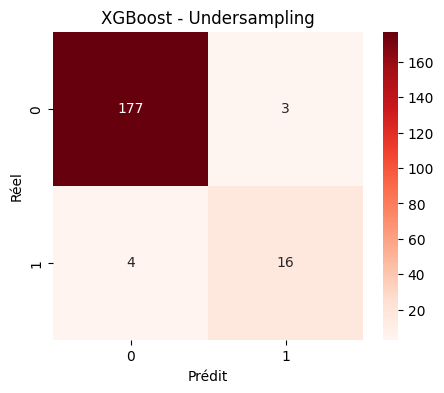


--- XGBoost - SMOTE ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       180
           1       0.94      0.85      0.89        20

    accuracy                           0.98       200
   macro avg       0.96      0.92      0.94       200
weighted avg       0.98      0.98      0.98       200



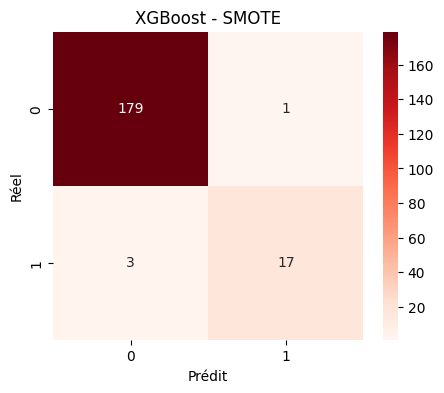


--- XGBoost - Poids Ajustés ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       180
           1       1.00      0.85      0.92        20

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.99      0.98      0.98       200



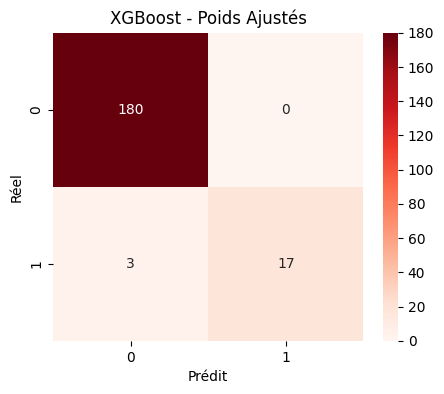

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# 1. Création d'un dataset déséquilibré
X, y = make_classification(
    n_samples=1000, n_features=10, n_clusters_per_class=1,
    weights=[0.9, 0.1], flip_y=0, random_state=42
)

print(f"Répartition originale : {np.bincount(y)}")  # [900 100]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Méthode 1 : Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"Répartition après Undersampling : {np.bincount(y_under)}")

model_under = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_under.fit(X_under, y_under)

# 3. Méthode 2 : SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"Répartition après SMOTE : {np.bincount(y_smote)}")

model_smote = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_smote.fit(X_smote, y_smote)

# 4. Méthode 3 : Ajustement des poids
ratio = np.bincount(y_train)[0] / np.bincount(y_train)[1]
print(f"Scale_pos_weight pour XGBoost : {ratio:.2f}")

model_weighted = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=ratio,
    random_state=42
)
model_weighted.fit(X_train, y_train)

# 5. Évaluation et comparaison
def evaluate_model(model, X_t, y_t, title):
    y_pred = model.predict(X_t)
    print(f"\n--- {title} ---")
    print(classification_report(y_t, y_pred))
    
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title(title)
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.show()
    
evaluate_model(model_under, X_test, y_test, "XGBoost - Undersampling")
evaluate_model(model_smote, X_test, y_test, "XGBoost - SMOTE")
evaluate_model(model_weighted, X_test, y_test, "XGBoost - Poids Ajustés")